# Faz 4 — Quantile Modeller (P10 / P50 / P90)

Ayni feature seti ve split ile, LightGBM'in `quantile` objective'i kullanilarak belirsizlik bandi (P10-P90) ureten 3 ayri model egitiliyor. Bu bant, uretim/stok kararlarinda 'ne kadar az/cok uretilirse israf/eksik olur' sorusuna cevap veriyor.

## 1. Veri ve Split'i Yeniden Kur

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pickle

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
FIG_DIR = '../reports/figures'

df = pd.read_parquet('../data/features.parquet')
with open('../data/split_config.pkl', 'rb') as f:
    cfg = pickle.load(f)

feature_cols = cfg['feature_cols']
cat_features = cfg['cat_features']
target_col = cfg['target_col']
SPLIT_WEEK = cfg['split_week']

train_df = df[df['week'] <= SPLIT_WEEK].copy()
test_df = df[df['week'] > SPLIT_WEEK].copy()
print('train:', train_df.shape, 'test:', test_df.shape)

train: (423727, 26) test: (32821, 26)


## 2. Uc Quantile Modeli — alpha = 0.1 / 0.5 / 0.9

In [2]:
quantiles = [0.1, 0.5, 0.9]
quantile_models = {}

base_params = {
    'objective': 'quantile',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42,
}

for alpha in quantiles:
    params = dict(base_params, alpha=alpha, metric='quantile')
    lgb_train = lgb.Dataset(train_df[feature_cols], label=train_df[target_col], categorical_feature=cat_features)
    lgb_valid = lgb.Dataset(test_df[feature_cols], label=test_df[target_col], categorical_feature=cat_features, reference=lgb_train)
    model = lgb.train(
        params, lgb_train, num_boost_round=2000,
        valid_sets=[lgb_valid], valid_names=['valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    quantile_models[alpha] = model
    print(f'alpha={alpha}: best_iteration={model.best_iteration}')

alpha=0.1: best_iteration=992


alpha=0.5: best_iteration=1240


alpha=0.9: best_iteration=486


### Tahminleri orijinal olcege cevirme ve quantile crossing duzeltmesi

Uc model birbirinden bagimsiz egitildigi icin bazi satirlarda P10 > P50 ya da P50 > P90 gibi 'crossing' durumlari olusabilir. Bunu satir bazinda siralayarak (`np.sort`) duzeltiyoruz.

In [3]:
preds_log = np.column_stack([
    quantile_models[a].predict(test_df[feature_cols], num_iteration=quantile_models[a].best_iteration)
    for a in quantiles
])
preds_orders = np.clip(np.expm1(preds_log), 0, None)
preds_orders_sorted = np.sort(preds_orders, axis=1)  # crossing fix: P10<=P50<=P90 garanti

n_crossed = (preds_orders != preds_orders_sorted).any(axis=1).sum()
print(f'Crossing duzeltilen satir sayisi: {n_crossed} / {len(preds_orders)} ({n_crossed/len(preds_orders):.2%})')

test_df = test_df.assign(
    pred_p10=preds_orders_sorted[:, 0],
    pred_p50=preds_orders_sorted[:, 1],
    pred_p90=preds_orders_sorted[:, 2],
)

Crossing duzeltilen satir sayisi: 29 / 32821 (0.09%)


## 3. Evaluation — Coverage ve Pinball Loss

In [4]:
actual = test_df['num_orders'].values

coverage = ((actual >= test_df['pred_p10']) & (actual <= test_df['pred_p90'])).mean()
print(f'Coverage (P10-P90 arasinda kalan gercek deger orani): {coverage:.2%}  (hedef: ~%80)')

def pinball_loss(y_true, y_pred, alpha):
    diff = y_true - y_pred
    return np.mean(np.maximum(alpha * diff, (alpha - 1) * diff))

pinball_results = {
    0.1: pinball_loss(actual, test_df['pred_p10'], 0.1),
    0.5: pinball_loss(actual, test_df['pred_p50'], 0.5),
    0.9: pinball_loss(actual, test_df['pred_p90'], 0.9),
}
for a, v in pinball_results.items():
    print(f'Pinball loss (alpha={a}): {v:.3f}')

Coverage (P10-P90 arasinda kalan gercek deger orani): 75.99%  (hedef: ~%80)
Pinball loss (alpha=0.1): 12.000
Pinball loss (alpha=0.5): 30.177
Pinball loss (alpha=0.9): 15.810


## 4. Tahmin Bandi Grafigi — Ornek bir center/meal icin

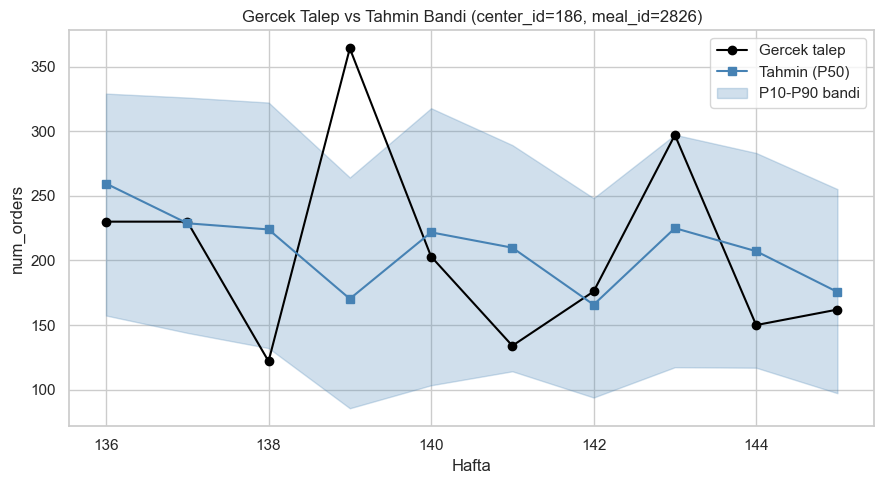

In [5]:
example = (
    test_df.groupby(['center_id', 'meal_id']).size().sort_values(ascending=False).index[0]
)
c_id, m_id = example
sample = test_df[(test_df['center_id'] == c_id) & (test_df['meal_id'] == m_id)].sort_values('week')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sample['week'], sample['num_orders'], marker='o', label='Gercek talep', color='black')
ax.plot(sample['week'], sample['pred_p50'], marker='s', label='Tahmin (P50)', color='steelblue')
ax.fill_between(sample['week'], sample['pred_p10'], sample['pred_p90'], alpha=0.25, color='steelblue', label='P10-P90 bandi')
ax.set_xlabel('Hafta'); ax.set_ylabel('num_orders')
ax.set_title(f'Gercek Talep vs Tahmin Bandi (center_id={c_id}, meal_id={m_id})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz4_prediction_band.png', dpi=120)
plt.show()

## Ozet

- Ayni feature seti ve time-based split ile 3 ayri LightGBM quantile modeli (P10/P50/P90) egitildi.
- Crossing (P10>P50 gibi) durumlar satir bazinda siralanarak duzeltildi.
- **Coverage** hedef ~%80'e ne kadar yakinsa model o kadar iyi kalibre demektir (yukaridaki cikti).
- **Pinball loss** her quantile icin ayri raporlandi; P50 pinball loss'u MAE/2'ye yakin olmasi beklenir.
- Ornek center/meal grafiginde gercek talebin buyuk olcude P10-P90 bandi icinde kaldigi gorsellestirildi.
- Bu bant, uretim planlamasinda 'P90 kadar uretirsen israf riski, P10 kadar uretirsen stoksuzluk riski' seklinde yorumlanabilir.

In [6]:
test_df.to_parquet('../data/test_with_quantile_pred.parquet', index=False)
for a, m in quantile_models.items():
    m.save_model(f'../data/quantile_lgb_p{int(a*100)}.txt')
print('Kaydedildi.')

Kaydedildi.
